In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize

## Read in the data

In [122]:
outlier_fpath = "./focal_length_outliers.txt"
with open(outlier_fpath,'r') as f:
  outliers = [l.strip() for l in f.readlines()]

data_fpath = "data/m41_site_cal_v227_v8_processed.xlsx"
data = pd.read_excel(data_fpath)
print(f"Num data points: {len(data)}")

# Remove outliers
data = data[~data['name'].isin(outliers)]
print(f"Num data points after removing outliers: {len(data)}")

Num data points: 3529
Num data points after removing outliers: 3496


In [123]:
# lambda functions to parse the vector and matrices from the string
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

# convert strings to vecs/mats
# data["h_r_vec" ] = [to_vec_comma(v) for v in data["h_r"]]
# data["v_r_vec" ] = [to_vec_comma(v) for v in data["v_r"]]
# data["a_r_vec" ] = [to_vec_comma(v) for v in data["a_r"]]
data["h_r_vec" ] = [to_vec_space(v) for v in data["h_r_est"]]
data["v_r_vec" ] = [to_vec_space(v) for v in data["v_r_est"]]
data["a_r_vec" ] = [to_vec_space(v) for v in data["a_r_est"]]
data["R_rpm_mat"] = [to_mat(m) for m in data["R_rpm"]]


zl34 = data[data["cam"] == "ZL034"].copy()
zl34.reset_index(drop=True, inplace=True)
zr34 = data[data["cam"] == "ZR034"].copy()
zr34.reset_index(drop=True, inplace=True)

print(f"Number of data points for zl034:{zl34.shape[0]}")
print(f"Number of data points for zr034:{zr34.shape[0]}")

Number of data points for zl034:326
Number of data points for zr034:308


## Helper functions to get matrix

In [124]:
left_fl = {"alpha": 4684.257100, "beta": 0.0497613}
right_fl = {"alpha": 4689.772199, "beta": 0.053044}


def get_fl(idx:int, data_:np.ndarray)->float:
  """
  Calculates the focal length using above linear model
  """
  fmc = data_["fmc"][idx]
  if (data_["cam"][idx][1] == "L"):
    return left_fl["beta"] * fmc + left_fl["alpha"]
  else:
    return right_fl["beta"] * fmc + right_fl["alpha"]

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_KC(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Forms the Kc matrix for that idx
  """
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_)
  Kc = np.array([[fl+b1, b2, cx],
               [0, fl, cy],
               [0, 0, 1]])
  return Kc

def get_KC_inv(idx:int, data_:np.ndarray)->np.ndarray:
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_)
  kc_inv = np.array([[1/(fl+b1), -b2/(fl*(fl+b1)), ((cy*b2)/(fl*(fl+b1)) - cx/(fl+b1))],
                     [0, 1/fl, -cy/fl],
                     [0, 0, 1]])
  return kc_inv

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  h_i = np.expand_dims(data_["h_r_vec"][idx], axis=1)
  v_i = np.expand_dims(data_["v_r_vec"][idx], axis=1)
  a_i = np.expand_dims(data_["a_r_vec"][idx], axis=1)
  H_i = np.concatenate([h_i, v_i, a_i], axis=1)

  return H_i

def get_q_rc_data(idx:int, data_: np.ndarray)->np.ndarray:
  """
  Forms the quaternion that corresponds to a rotation from r to c from data
  """
  H_r = get_H_r_data(idx, data_)
  H_c = get_KC(idx, data_).T
  return R.from_matrix(H_r @ np.linalg.inv(H_c)).as_quat()

def get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                  q_mc_a0, q_mc_a1, q_mc_a2, q_mc_a3,
                  q_mc_b0, q_mc_b1, q_mc_b2, q_mc_b3, 
                  idx:int, data_:np.ndarray):
  """
  Forms the quaternion that corresponds to a rotation from r to c from model
  """
  rot_rrp = R.from_quat(np.array([q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3]))

  rot_rpm = R.from_matrix(get_R_rpm(idx, data_))

  rot_mc = R.from_quat(np.array([q_mc_a0, q_mc_a1, q_mc_a2, q_mc_a3]) + \
    np.array([q_mc_b0, q_mc_b1, q_mc_b2, q_mc_b3]) * data_["fmc"][idx])
  
  return (rot_rrp * rot_rpm * rot_mc).as_quat(canonical=True)


## Optimization

In [127]:
def dist_q(q1:np.ndarray, q2:np.ndarray)->float:
  assert q1.shape == (4,)
  assert q2.shape == (4,)

  q1 = q1 / np.linalg.norm(q1)
  q2 = q2 / np.linalg.norm(q2)

  return np.arccos(2 * (np.dot(q1, q2)**2) - 1)

data034 = pd.concat([zl34, zr34], axis=0)
data034.reset_index(drop=True, inplace=True)

# objective function for the model
def obj(x)->float:
  
  q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3 = x[:4]
  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3 = x[4:8]
  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3 = x[8:12]
  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3 = x[12:16]
  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3 = x[16:20]

  total_dist = 0
  count = 0
  for i in range(data034.shape[0]):
    q_rc_data = get_q_rc_data(i, data034)
    if data034["cam"][i] == "ZL034":
      q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3,
                                  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3,
                                  i, data034)
      total_dist += dist_q(q_rc_data, q_rc_model)
      count += 1
    
    elif data034["cam"][i] == "ZR034":
      q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3,
                                  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3,
                                  i, data034)
      total_dist += dist_q(q_rc_data, q_rc_model)
      count += 1
  
  return total_dist/count

x0 = [  0.00035132, -0.0004781 ,  0.00048555, -0.99999971,
      0.5, 0.5, 0.5, -0.5,
      0, 0, 0, 0,
      0.5, 0.5, 0.5, -0.5,
      0, 0, 0, 0,]
res = minimize(obj, x0, method="BFGS", options={"return_all":True,
                                                "gtol":1e-20,
                                                "xrtol":1e-20,
                                                "maxiter":50})

In [128]:
q_rrp = np.array(res.x[:4])/np.linalg.norm(np.array(res.x[:4]))
q_cm_zl_a = np.array(res.x[4:8])/np.linalg.norm(np.array(res.x[4:8]))
q_cm_zl_b = np.array(res.x[8:12])
q_cm_zr_a = np.array(res.x[12:16])/np.linalg.norm(np.array(res.x[12:16]))
q_cm_zr_b = np.array(res.x[16:20])


print(f"Final function:{res.fun:.6f}")
print(f"Final Jacobian:{np.linalg.norm(res.jac):.6f}")
print(f"q_rrp:{q_rrp}")
print(f"q_cm_zl_a:{q_cm_zl_a}")
print(f"q_cm_zl_b:{q_cm_zl_b}")
print(f"q_cm_zr_a:{q_cm_zr_a}")
print(f"q_cm_zr_b:{q_cm_zr_b}")

Final function:0.000869
Final Jacobian:0.363918
q_rrp:[ 1.76718034e-04  4.65679253e-05 -5.97418832e-04 -9.99999805e-01]
q_cm_zl_a:[0.4964451  0.52529455 0.4770028  0.50007622]
q_cm_zl_b:[0.40350956 0.41483631 0.41661917 0.40969616]
q_cm_zr_a:[0.49768647 0.48643536 0.51264137 0.50287936]
q_cm_zr_b:[0.42448575 0.41287615 0.42050913 0.42757254]


In [129]:
rot_rrp = R.from_quat(res.x[:4])
rot_rrp.as_matrix()

array([[ 9.99999282e-01, -1.19482097e-03, -9.33469819e-05],
       [ 1.19485389e-03,  9.99999224e-01,  3.53380357e-04],
       [ 9.29246832e-05, -3.53491639e-04,  9.99999933e-01]])

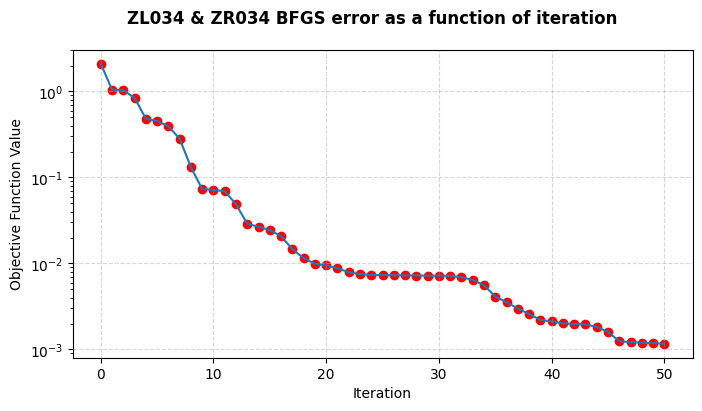

In [ ]:
# plot the error as a function of iteration
errs = [obj(x) for x in res.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(8,4))


ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")

fig.suptitle("ZL034 & ZR034 BFGS error as a function of iteration", fontsize=12, fontweight="bold");

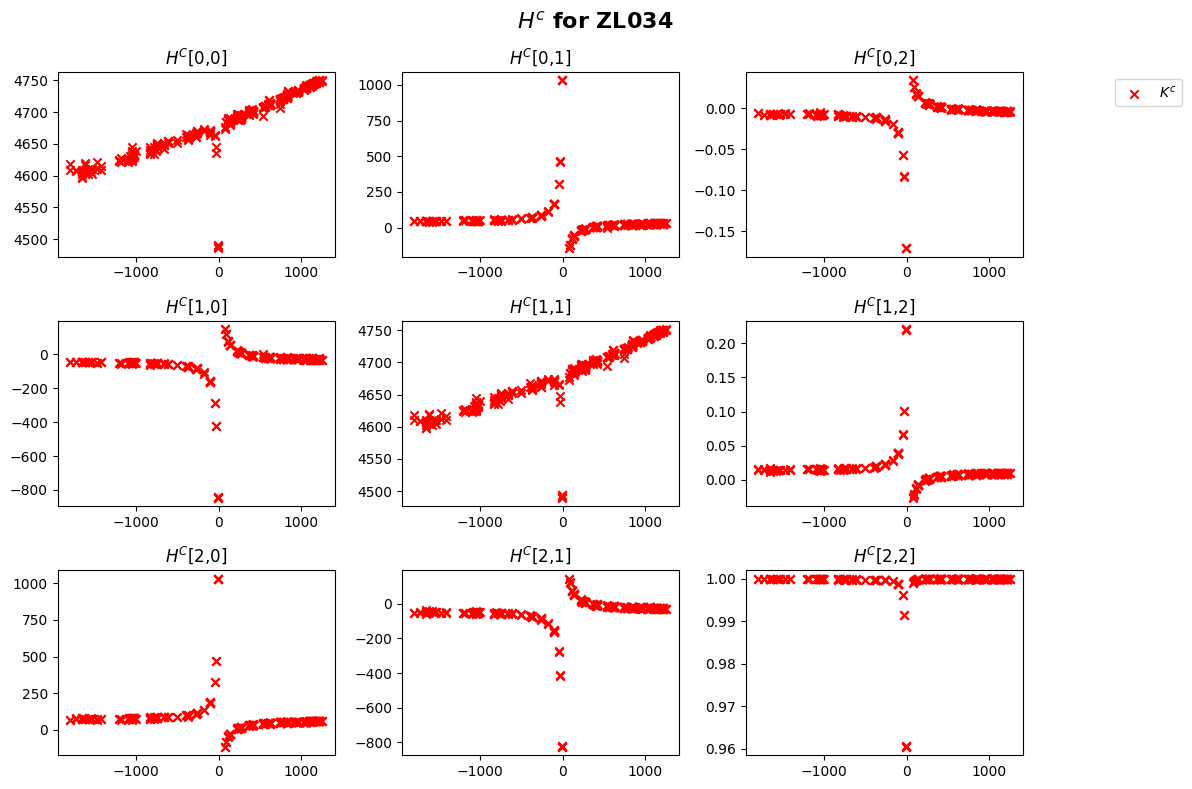

In [161]:
# Compute H_c for ZL034
H_c_model = []
H_c_pseudo_gt = []
H_c_gt = []

zl034 = data[data["cam"]=="ZL034"].copy().reset_index(drop=True)

rot_rrp = R.from_quat(q_rrp)
for i in range(zl034.shape[0]):
  # compute the rotation R_rc
  f = zl034["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zl034))
  rot_mc = R.from_quat(q_cm_zl_a + q_cm_zl_b * f)
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()

  # tranform to camera frame
  H_r = get_H_r_data(i, zl034)
  H_c_model.append(np.linalg.inv(R_rc) @ H_r)

  H_c_gt.append(get_KC(i, zl034).T)


fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    # ax[r,c].scatter(zl034["fmc"], [H[r,c] for H in H_c_gt], label="expectation")
    ax[r,c].scatter(zl034["fmc"], [H[r, c] for H in H_c_model], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^C$[{r},{c}]")

ax[0,2].legend(["$K^c$", "$(R^r_{rp} R^{rp}_M R^M_C)^T H^r$"], bbox_to_anchor=(1.6,1))


fig.suptitle("$H^c$ for ZL034", fontsize=16, fontweight="bold")
fig.tight_layout()

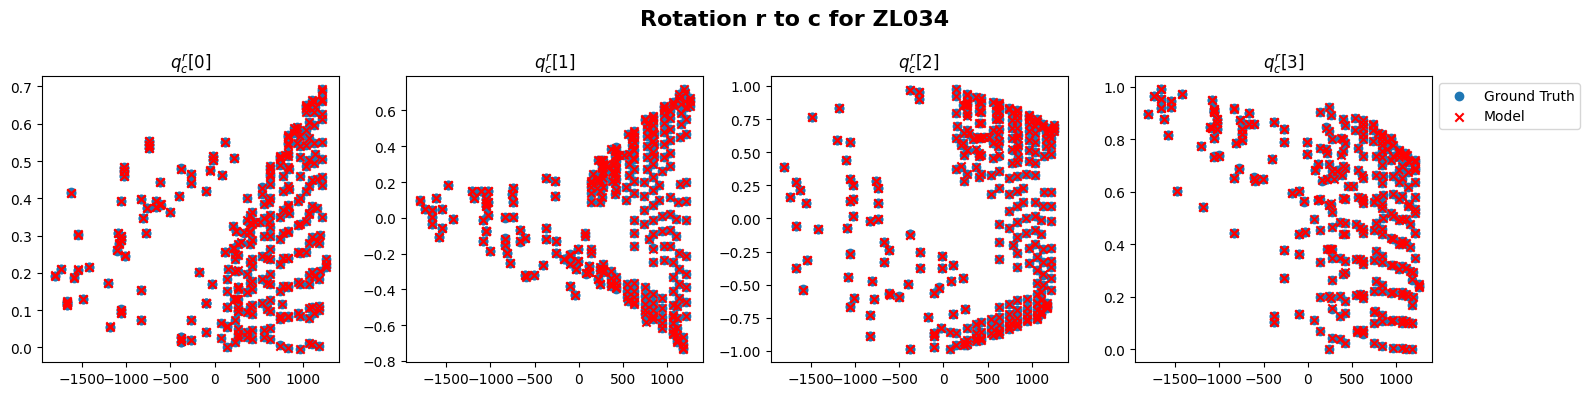

In [ ]:
# compute quaternion for rotations from r to c from data 
q_rc_model = []
q_rc_data = []

zl034 = data[data["cam"]=="ZL034"].copy().reset_index(drop=True)

rot_rrp = R.from_quat(q_rrp)
for i in range(zl034.shape[0]):
  # compute quaternions from data
  H_r = get_H_r_data(i, zl034)
  H_c = get_KC(i, zl034).T
  rot_rc_data = R.from_matrix(H_r @ np.linalg.inv(H_c))
  q_rc_d = rot_rc_data.as_quat(canonical=True)
  q_rc_data.append(q_rc_d)

  # compute quaternion from model
  f = zl034["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zl034))
  rot_mc = R.from_quat(q_cm_zl_a + q_cm_zl_b * f)
  rot_rc = rot_rrp * rot_rpm * rot_mc
  q_rc_m = rot_rc.as_quat(canonical=True)
  q_rc_model.append(q_rc_m)

# plot each of the quaternion
fig, ax = plt.subplots(1,4, figsize=(16,4))

for i in range(4):
  ax[i].scatter(zl034["fmc"], [q[i] for q in q_rc_data], label="data")
  ax[i].scatter(zl034["fmc"], [q[i] for q in q_rc_model], color="red", marker='x', label="model")
  ax[i].set_title(f"$q^r_c$[{i}]")

ax[3].legend(["Ground Truth", "Model"], bbox_to_anchor=(1,1))
fig.suptitle("Rotation r to c for ZL034", fontsize=16, fontweight="bold")
fig.tight_layout()

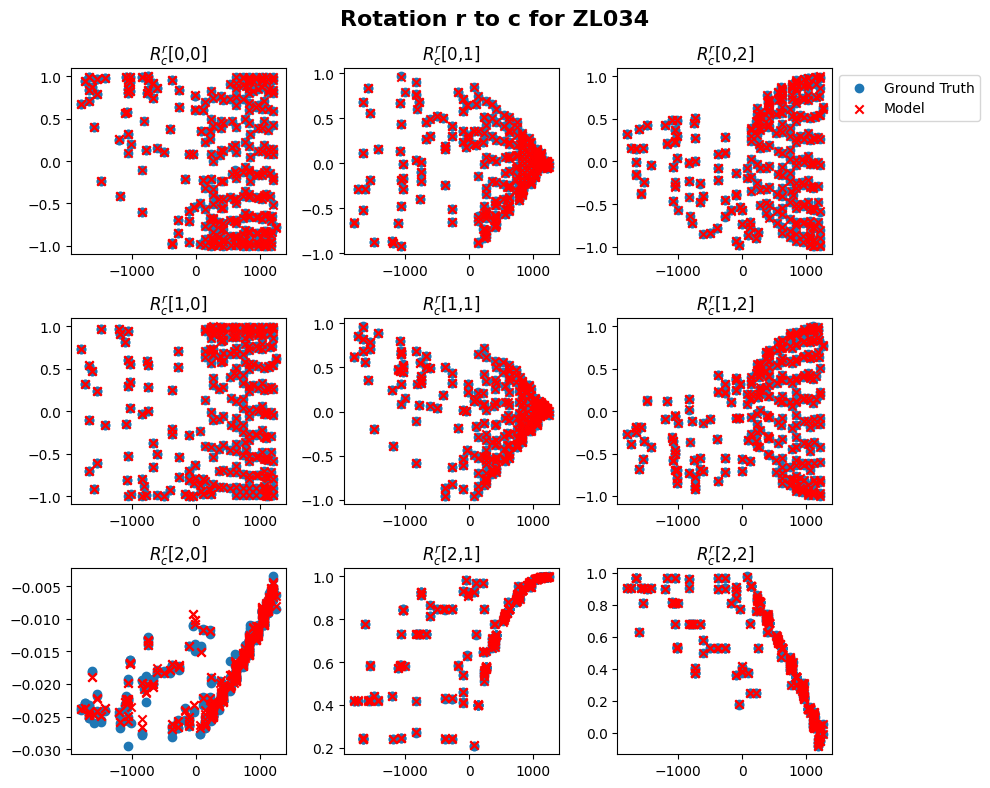

In [131]:
# compute rotation matrix from r to c from data 
R_rc_model = []
R_rc_data = []

zl034 = data[data["cam"]=="ZL034"].copy().reset_index(drop=True)

rot_rrp = R.from_quat(q_rrp)
for i in range(zl034.shape[0]):
  # compute rotation matrix from data
  H_r = get_H_r_data(i, zl034)
  H_c = get_KC(i, zl034).T
  rot_rc_data = R.from_matrix(H_r @ np.linalg.inv(H_c))
  R_rc_data.append(rot_rc_data.as_matrix())

  # compute rotation matrix from model
  f = zl034["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zl034))
  rot_mc = R.from_quat(q_cm_zl_a + q_cm_zl_b * f)
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc_model.append(rot_rc.as_matrix())

# plot each of the quaternion
fig, ax = plt.subplots(3,3, figsize=(10,8))

for i in range(3):
  for j in range(3):
    ax[i,j].scatter(zl034["fmc"], [R[i,j] for R in R_rc_data], label="data")
    ax[i,j].scatter(zl034["fmc"], [R[i,j] for R in R_rc_model], color="red", marker='x', label="model")
    ax[i,j].set_title(f"$R^r_c$[{i},{j}]")
  

ax[0][2].legend(["Ground Truth", "Model"], bbox_to_anchor=(1,1))
fig.suptitle("Rotation r to c for ZL034", fontsize=16, fontweight="bold")
fig.tight_layout()

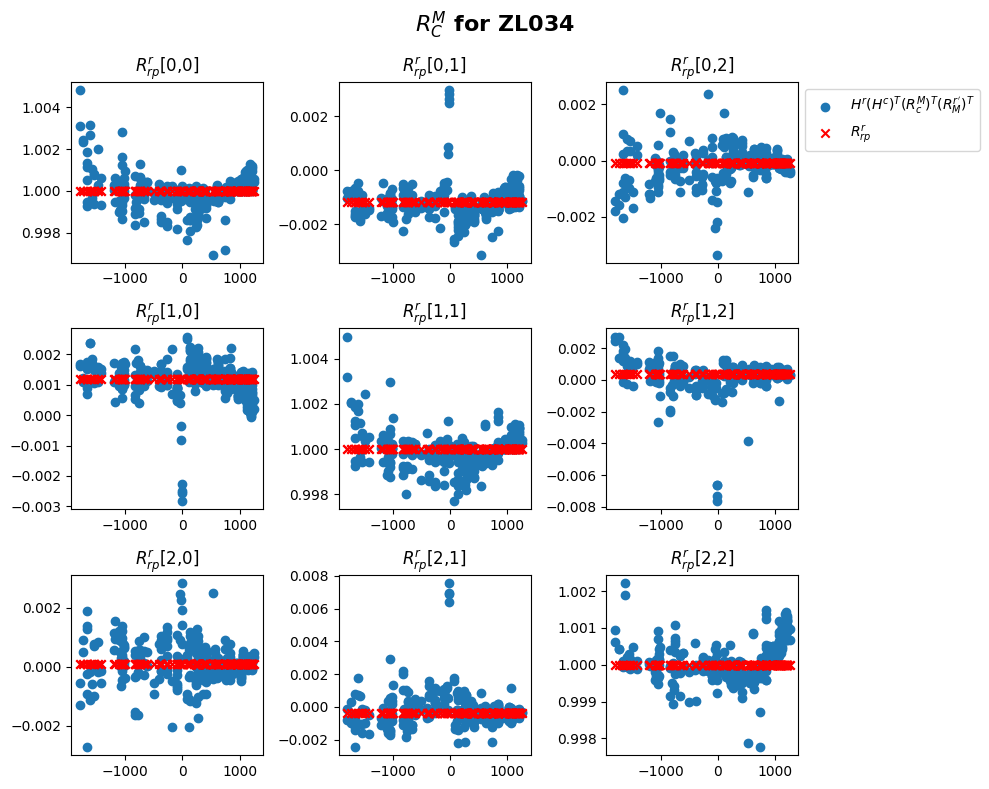

In [132]:
## understand rotation R_rm
zl034 = data[data["cam"]=="ZL034"].copy().reset_index(drop=True)

R_rrp_rhs = []
R_rrp_lhs = []

for i in range(zl034.shape[0]):
  # compute the H matrices
  H_r = get_H_r_data(i, zl034)
  H_c = get_KC(i, zl034).T

  # compute rotation rpc
  rot_rpm = R.from_matrix(get_R_rpm(i, zl034))
  f = zl034["fmc"][i]
  rot_mc = R.from_quat(q_cm_zl_a + q_cm_zl_b * f)
  rot_rpc = rot_rpm * rot_mc
  R_rpc = rot_rpc.as_matrix()

  # compute rrp from H matrices and R_rpc
  R_rrp = H_r @ np.linalg.inv(H_c) @ np.linalg.inv(R_rpc)
  R_rrp_rhs.append(R_rrp)

  # model
  R_rrp_lhs.append(R.from_quat(q_rrp).as_matrix())

fig, ax = plt.subplots(3,3, figsize=(10,8))

for i in range(3):
  for j in range(3):
    ax[i,j].scatter(zl034["fmc"], [R[i,j] for R in R_rrp_rhs], label="$H^r(H^c)^T(R^M_c)^T(R^{r'}_M)^T$")
    ax[i,j].scatter(zl034["fmc"], [R[i,j] for R in R_rrp_lhs], color="red", marker='x', label="$R^r_{rp}$")
    ax[i,j].set_title("$R^r_{rp}$"+f"[{i},{j}]")

ax[0,2].legend( bbox_to_anchor=(1,1))
fig.suptitle("$R^M_C$ for ZL034", fontsize=16, fontweight="bold")
fig.tight_layout()
  

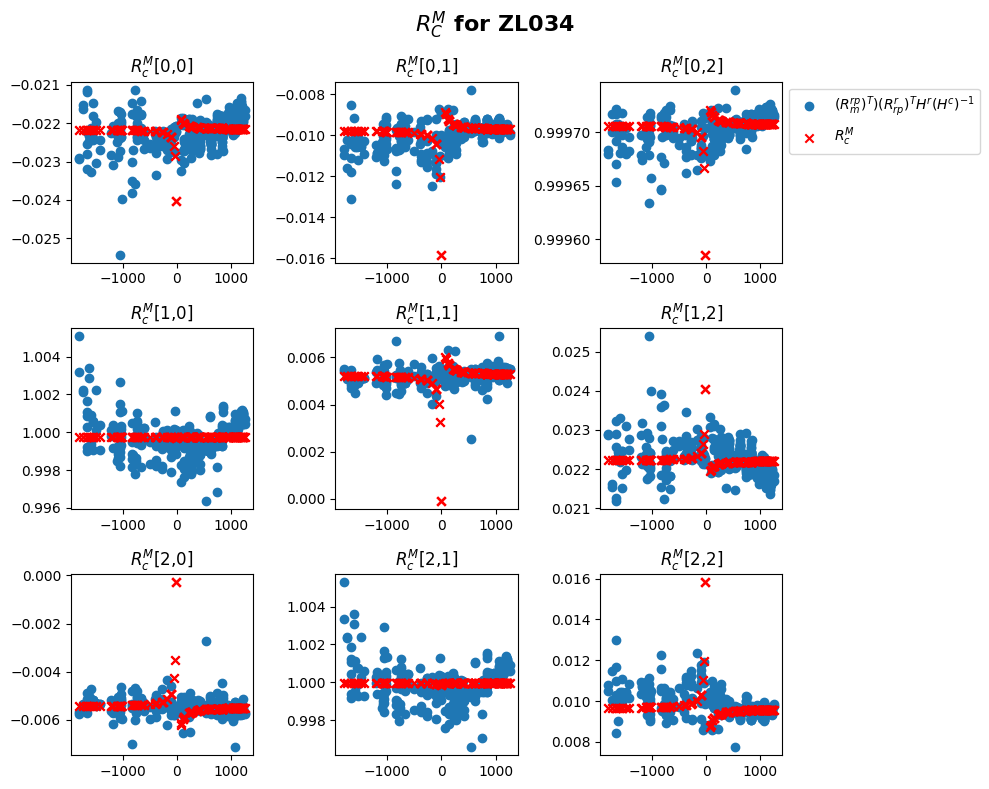

In [133]:
# understand rotation R_cm
zl034 = data[data["cam"]=="ZL034"].copy().reset_index(drop=True)

R_rc_rhs = []
R_rc_lhs = []

for i in range(zl034.shape[0]):
  # compute the H matrices 
  H_r = get_H_r_data(i, zl034)
  H_c = get_KC(i, zl034).T

  # comput R_rm
  rot_rrp = R.from_quat(q_rrp)
  rot_rpm = R.from_matrix(get_R_rpm(i, zl034))
  rot_rm = rot_rrp * rot_rpm
  R_rm = rot_rm.as_matrix()

  # compute R_rc from H matrices and R_rm
  R_rc = np.linalg.inv(R_rm) @ H_r @ np.linalg.inv(H_c)
  R_rc_rhs.append(R_rc)

  # compute R_cm 
  f = zl034["fmc"][i]
  rot_mc = R.from_quat(q_cm_zl_a + q_cm_zl_b * f)
  R_cm = rot_mc.as_matrix()
  R_rc_lhs.append(R_cm)

fig, ax = plt.subplots(3,3, figsize=(10,8))

for i in range(3):
  for j in range(3):
    ax[i,j].scatter(zl034["fmc"], [R[i,j] for R in R_rc_rhs], label="$(R^{rp}_m)^T)(R_{rp}^r)^TH^r(H^c)^{-1}$")
    ax[i,j].scatter(zl034["fmc"], [R[i,j] for R in R_rc_lhs], color="red", marker='x', label="$R^M_c$")
    ax[i,j].set_title("$R^M_c$"+f"[{i},{j}]")

ax[0,2].legend( bbox_to_anchor=(1,1))
fig.suptitle("$R^M_C$ for ZL034", fontsize=16, fontweight="bold")
fig.tight_layout()

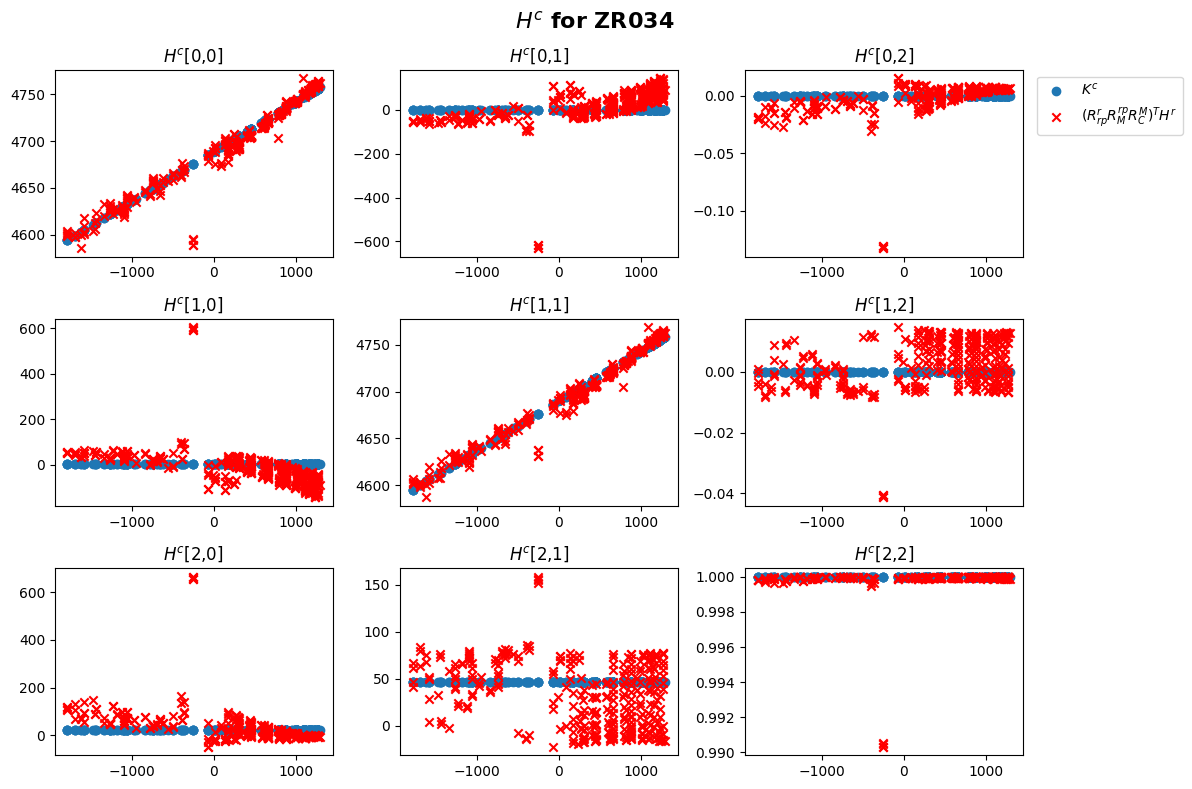

In [146]:
# Compute H_r from model
H_c_model = []
H_c_gt = []

zr034 = data[data["cam"]=="ZR034"].copy().reset_index(drop=True)

rot_rrp = R.from_quat(q_rrp)
for i in range(zr034.shape[0]):
  # compute the rotation R_rc
  f = zr034["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zr034))
  rot_mc = R.from_quat(q_cm_zr_a + q_cm_zr_b * f)
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()

  # tranform to camera frame
  H_r = get_H_r_data(i, zr034)
  H_c_model.append(R_rc.T @ H_r)

  H_c_gt.append(get_KC(i, zr034).T)


fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zr034["fmc"], [H[r,c] for H in H_c_gt], label="expectation")
    ax[r,c].scatter(zr034["fmc"], [H[r, c] for H in H_c_model], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^c$[{r},{c}]")

ax[0,2].legend(["$K^c$", "$(R^r_{rp} R^{rp}_M R^M_C)^T H^r$"], bbox_to_anchor=(1.6,1))

fig.suptitle("$H^c$ for ZR034", fontsize=16, fontweight="bold")
fig.tight_layout()

Text(0.5, 0.98, 'Ground truth vs model for ZR034')

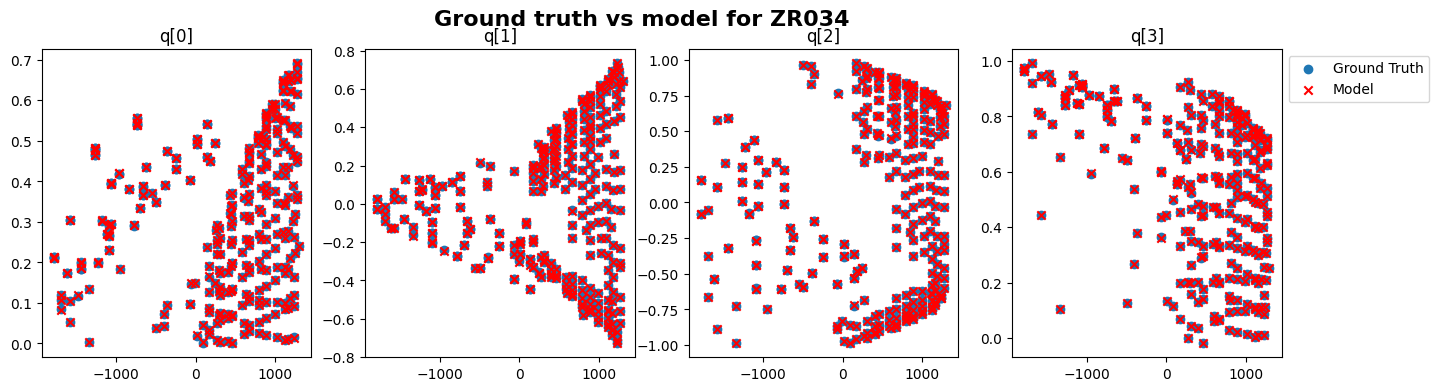

In [135]:
# compute quaternion for rotations from r to c from data 
q_rc_model = []
q_rc_data = []

zr034 = data[data["cam"]=="ZR034"].copy().reset_index(drop=True)

rot_rrp = R.from_quat(q_rrp)
for i in range(zr034.shape[0]):
  # compute quaternions from data
  H_r = get_H_r_data(i, zr034)
  H_c = get_KC(i, zr034).T
  rot_rc_data = R.from_matrix(H_r @ np.linalg.inv(H_c))
  q_rc_d = rot_rc_data.as_quat()
  if q_rc_d[0] < 0:
    q_rc_d = -q_rc_d
  q_rc_data.append(q_rc_d)

  # compute quaternion from model
  f = zr034["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zr034))
  rot_mc = R.from_quat(q_cm_zr_a + q_cm_zr_b * f)
  rot_rc = rot_rrp * rot_rpm * rot_mc
  q_rc_m = rot_rc.as_quat()
  if q_rc_m[0] < 0:
    q_rc_m = -q_rc_m
  q_rc_model.append(q_rc_m)

# plot each of the quaternion
fig, ax = plt.subplots(1,4, figsize=(16,4))

for i in range(4):
  ax[i].scatter(zr034["fmc"], [q[i] for q in q_rc_data], label="data")
  ax[i].scatter(zr034["fmc"], [q[i] for q in q_rc_model], color="red", marker='x', label="model")
  ax[i].set_title(f"q[{i}]")

ax[3].legend(["Ground Truth", "Model"], bbox_to_anchor=(1,1))
fig.suptitle("Ground truth vs model for ZR034", fontsize=16, fontweight="bold")

## $q^m_c$ as a single quaternion

In [136]:
def get_q_rc_model_single(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                  q_mc_a0, q_mc_a1, q_mc_a2, q_mc_a3,
                  idx:int, data_:np.ndarray):
  """
  Forms the quaternion that corresponds to a rotation from r to c from model
  """
  rot_rrp = R.from_quat(np.array([q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3]))

  rot_rpm = R.from_matrix(get_R_rpm(idx, data_))

  rot_mc = R.from_quat(np.array([q_mc_a0, q_mc_a1, q_mc_a2, q_mc_a3]))
  
  return (rot_rrp * rot_rpm * rot_mc).as_quat(canonical=True)

def dist_q(q1:np.ndarray, q2:np.ndarray)->float:
  assert q1.shape == (4,)
  assert q2.shape == (4,)

  q1 = q1 / np.linalg.norm(q1)
  q2 = q2 / np.linalg.norm(q2)

  return np.arccos(2 * (np.dot(q1, q2)**2) - 1)

data034 = pd.concat([zl34, zr34], axis=0)
data034.reset_index(drop=True, inplace=True)

# objective function for the model
def obj(x)->float:
  
  q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3 = x[:4]
  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3 = x[4:8]
  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3 = x[8:12]

  total_dist = 0
  count = 0
  for i in range(data034.shape[0]):
    q_rc_data = get_q_rc_data(i, data034)
    if data034["cam"][i] == "ZL034":
      q_rc_model = get_q_rc_model_single(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3,
                                  i, data034)
      total_dist += dist_q(q_rc_data, q_rc_model)
      count += 1
    
    elif data034["cam"][i] == "ZR034":
      q_rc_model = get_q_rc_model_single(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3,
                                  i, data034)
      total_dist += dist_q(q_rc_data, q_rc_model)
      count += 1
  
  return total_dist/count

x0 = [  0.00035132, -0.0004781 ,  0.00048555, -0.99999971,
      0.5, 0.5, 0.5, -0.5,
      0.5, 0.5, 0.5, -0.5]
res_single = minimize(obj, x0, method="BFGS", options={"return_all":True,
                                                "gtol":1e-20,
                                                "xrtol":1e-20,
                                                "maxiter":50})

In [137]:
q_rrp = np.array(res.x[:4])/np.linalg.norm(res.x[:4])
q_cm_zl_a = np.array(res.x[4:8])/np.linalg.norm(res.x[4:8])
q_cm_zr_a = np.array(res.x[12:16])/np.linalg.norm(res.x[12:16])

print(f"Final function:{res_single.fun:.6f}")
print(f"Final Jacobian:{np.linalg.norm(res_single.jac):.6f}")
print(f"q_rrp:{q_rrp}")
print(f"q_cm_zl_a:{q_cm_zl_a}")
print(f"q_cm_zr_a:{q_cm_zr_a}")

Final function:0.000818
Final Jacobian:0.000060
q_rrp:[ 1.76718034e-04  4.65679253e-05 -5.97418832e-04 -9.99999805e-01]
q_cm_zl_a:[0.4964451  0.52529455 0.4770028  0.50007622]
q_cm_zr_a:[0.49768647 0.48643536 0.51264137 0.50287936]


In [171]:
R.from_quat([0.5, 0.5, 0.5, -0.5]).as_matrix()

array([[0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

In [172]:
R.from_quat([0.5, 0.5, 0.5, 0.5]).as_matrix()

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

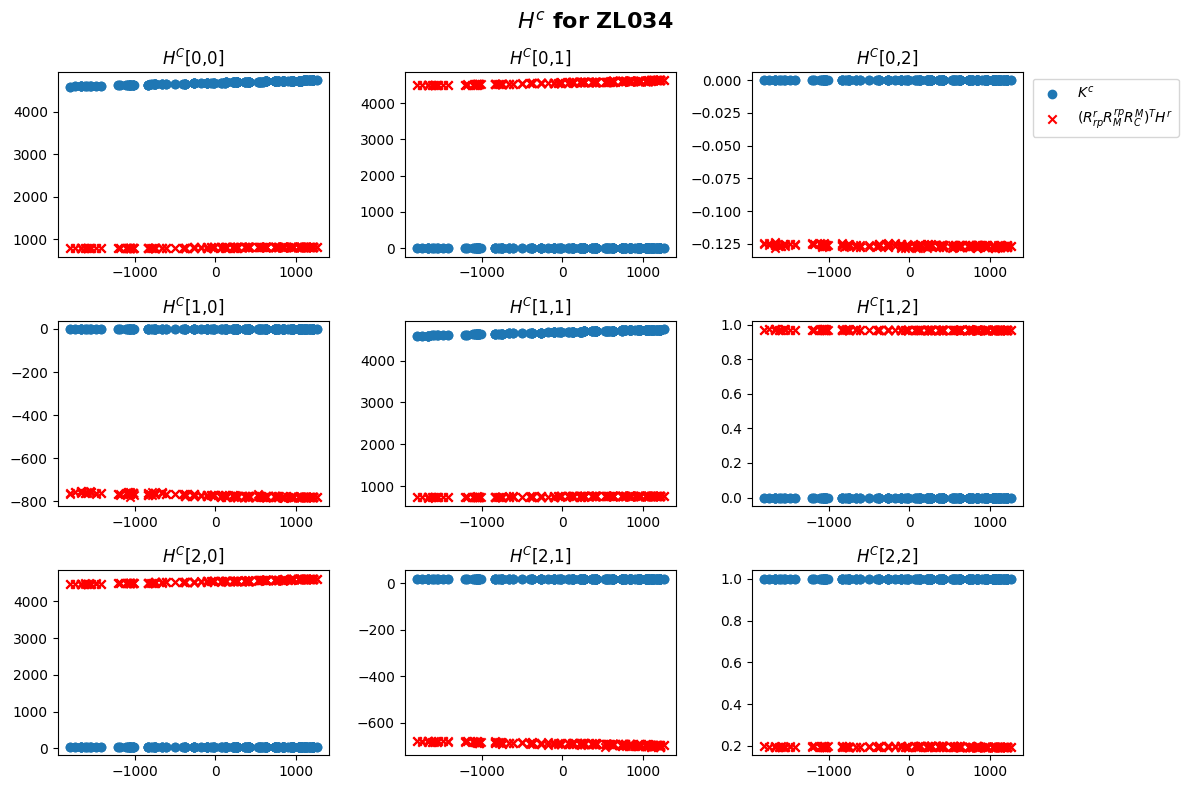

In [173]:
# Compute H_r from model
H_c_model = []
H_c = []

zl034 = data[data["cam"]=="ZL034"].copy().reset_index(drop=True)

rot_rrp = R.from_quat(q_rrp)
for i in range(zl034.shape[0]):
  # compute the rotation R_rc
  rot_rpm = R.from_matrix(get_R_rpm(i, zl034))
  rot_mc = R.from_quat(q_cm_zl_a )
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()

  # compute H_c = (R_rc).T @ H_r
  H_r = get_H_r_data(i, zl034)
  H_c_model.append(np.linalg.inv(R_rc) @ H_r)

  # compute H_c
  H_c.append(get_KC(i, zl034).T)


fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zl034["fmc"], [H[r,c] for H in H_c], label="expectation")
    ax[r,c].scatter(zl034["fmc"], [H[r, c] for H in H_c_model], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^C$[{r},{c}]")

ax[0,2].legend(["$K^c$", "$(R^r_{rp} R^{rp}_M R^M_C)^T H^r$"], bbox_to_anchor=(1.6,1))


fig.suptitle("$H^c$ for ZL034", fontsize=16, fontweight="bold")
fig.tight_layout()

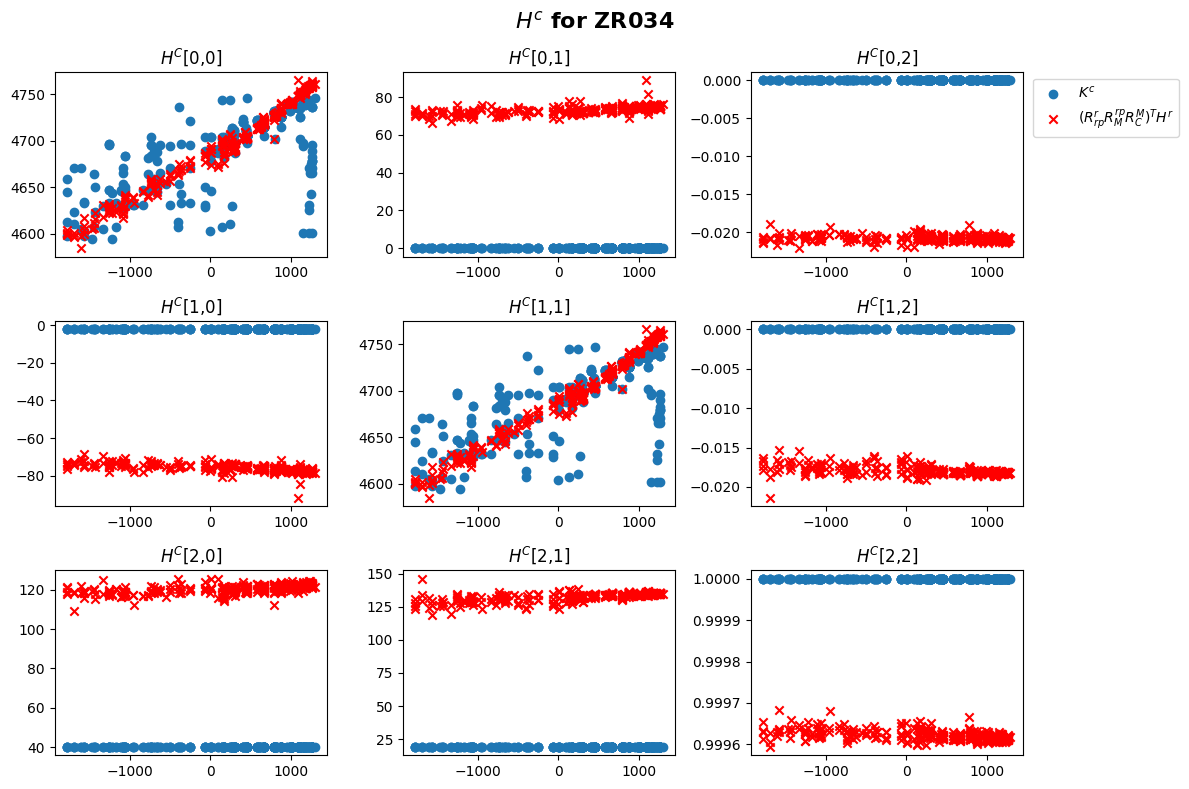

In [139]:
# Compute H_r from model
H_c_model = []
H_c = []

zr034 = data[data["cam"]=="ZR034"].copy().reset_index(drop=True)

rot_rrp = R.from_quat(q_rrp)
for i in range(zr034.shape[0]):
  # compute the rotation R_rc
  rot_rpm = R.from_matrix(get_R_rpm(i, zr034))
  rot_mc = R.from_quat(q_cm_zr_a )
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()

  # compute H_c = (R_rc).T @ H_r
  H_r = get_H_r_data(i, zr034)
  H_c_model.append(np.linalg.inv(R_rc) @ H_r)

  # compute H_c
  H_c.append(get_KC(i, zl034).T)


fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zr034["fmc"], [H[r,c] for H in H_c], label="expectation")
    ax[r,c].scatter(zr034["fmc"], [H[r, c] for H in H_c_model], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^C$[{r},{c}]")

ax[0,2].legend(["$K^c$", "$(R^r_{rp} R^{rp}_M R^M_C)^T H^r$"], bbox_to_anchor=(1.6,1))


fig.suptitle("$H^c$ for ZR034", fontsize=16, fontweight="bold")
fig.tight_layout()

## Fitting Quaternions that minimizes $q^m_{c,b}$

In [148]:
def dist_q(q1:np.ndarray, q2:np.ndarray)->float:
  assert q1.shape == (4,)
  assert q2.shape == (4,)

  q1 = q1 / np.linalg.norm(q1)
  q2 = q2 / np.linalg.norm(q2)

  return np.arccos(2 * (np.dot(q1, q2)**2) - 1)

data034 = pd.concat([zl34, zr34], axis=0)
data034.reset_index(drop=True, inplace=True)
lambda_l = 5
lambda_r = 5

# objective function for the model
def obj(x)->float:
  
  q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3 = x[:4]
  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3 = x[4:8]
  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3 = x[8:12]
  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3 = x[12:16]
  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3 = x[16:20]

  total_dist = 0
  count = 0
  for i in range(data034.shape[0]):
    q_rc_data = get_q_rc_data(i, data034)
    if data034["cam"][i] == "ZL034":
      q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3,
                                  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3,
                                  i, data034)
      total_dist += dist_q(q_rc_data, q_rc_model)
      count += 1
    
    elif data034["cam"][i] == "ZR034":
      q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3,
                                  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3,
                                  i, data034)
      total_dist += dist_q(q_rc_data, q_rc_model)
      count += 1
  
  return (total_dist/count) +\
        lambda_l * np.linalg.norm(x[8:12])**2 +\
        lambda_r * np.linalg.norm(x[16:20])**2

x0 = [  0.00035132, -0.0004781 ,  0.00048555, -0.99999971,
      0.5, 0.5, 0.5, -0.5,
      0, 0, 0, 0,
      0.5, 0.5, 0.5, -0.5,
      0, 0, 0, 0,]
res = minimize(obj, x0, method="BFGS", options={"return_all":True,
                                                "gtol":1e-20,
                                                "xrtol":1e-20,
                                                "maxiter":50})

In [149]:
q_rrp = np.array(res.x[:4])/np.linalg.norm(np.array(res.x[:4]))
q_cm_zl_a = np.array(res.x[4:8])/np.linalg.norm(np.array(res.x[4:8]))
q_cm_zl_b = np.array(res.x[8:12])
q_cm_zr_a = np.array(res.x[12:16])/np.linalg.norm(np.array(res.x[12:16]))
q_cm_zr_b = np.array(res.x[16:20])


print(f"Final function:{res.fun:.6f}")
print(f"Final Jacobian:{np.linalg.norm(res.jac):.6f}")
print(f"q_rrp:{q_rrp}")
print(f"q_cm_zl_a:{q_cm_zl_a}")
print(f"q_cm_zl_b:{q_cm_zl_b}")
print(f"q_cm_zr_a:{q_cm_zr_a}")
print(f"q_cm_zr_b:{q_cm_zr_b}")

Final function:0.017152
Final Jacobian:31.920042
q_rrp:[ 1.02502791e-03  3.32828519e-04 -1.13429608e-02 -9.99935086e-01]
q_cm_zl_a:[0.48665397 0.45723111 0.53893734 0.51347267]
q_cm_zl_b:[0.01078791 0.01097395 0.01096531 0.01103761]
q_cm_zr_a:[0.50771573 0.48338356 0.49172926 0.51649531]
q_cm_zr_b:[0.00987704 0.00955152 0.00963673 0.01004646]


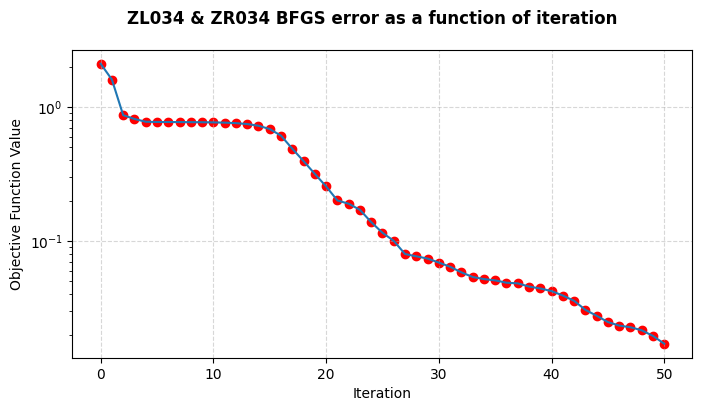

In [150]:
# plot the error as a function of iteration
errs = [obj(x) for x in res.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(8,4))


ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")

fig.suptitle("ZL034 & ZR034 BFGS error as a function of iteration", fontsize=12, fontweight="bold");

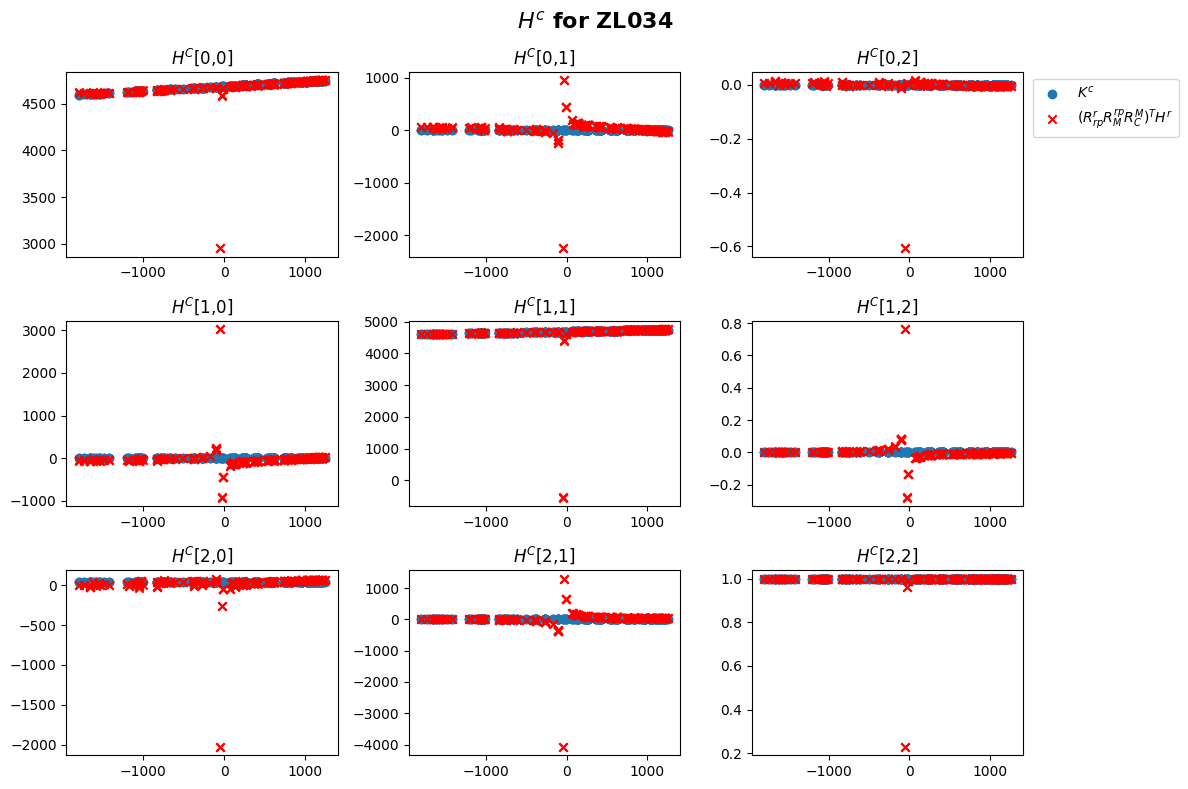

In [153]:
# Compute H_c for ZL034
H_c_model = []
H_c_pseudo_gt = []
H_c_gt = []

zl034 = data[data["cam"]=="ZL034"].copy().reset_index(drop=True)

rot_rrp = R.from_quat(q_rrp)
for i in range(zl034.shape[0]):
  # compute the rotation R_rc
  f = zl034["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zl034))
  rot_mc = R.from_quat(q_cm_zl_a + q_cm_zl_b * f)
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()

  # tranform to camera frame
  H_r = get_H_r_data(i, zl034)
  H_c_model.append(np.linalg.inv(R_rc) @ H_r)

  H_c_gt.append(get_KC(i, zl034).T)


fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zl034["fmc"], [H[r,c] for H in H_c_gt], label="expectation")
    ax[r,c].scatter(zl034["fmc"], [H[r, c] for H in H_c_model], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^C$[{r},{c}]")

ax[0,2].legend(["$K^c$", "$(R^r_{rp} R^{rp}_M R^M_C)^T H^r$"], bbox_to_anchor=(1.6,1))


fig.suptitle("$H^c$ for ZL034", fontsize=16, fontweight="bold")
fig.tight_layout()

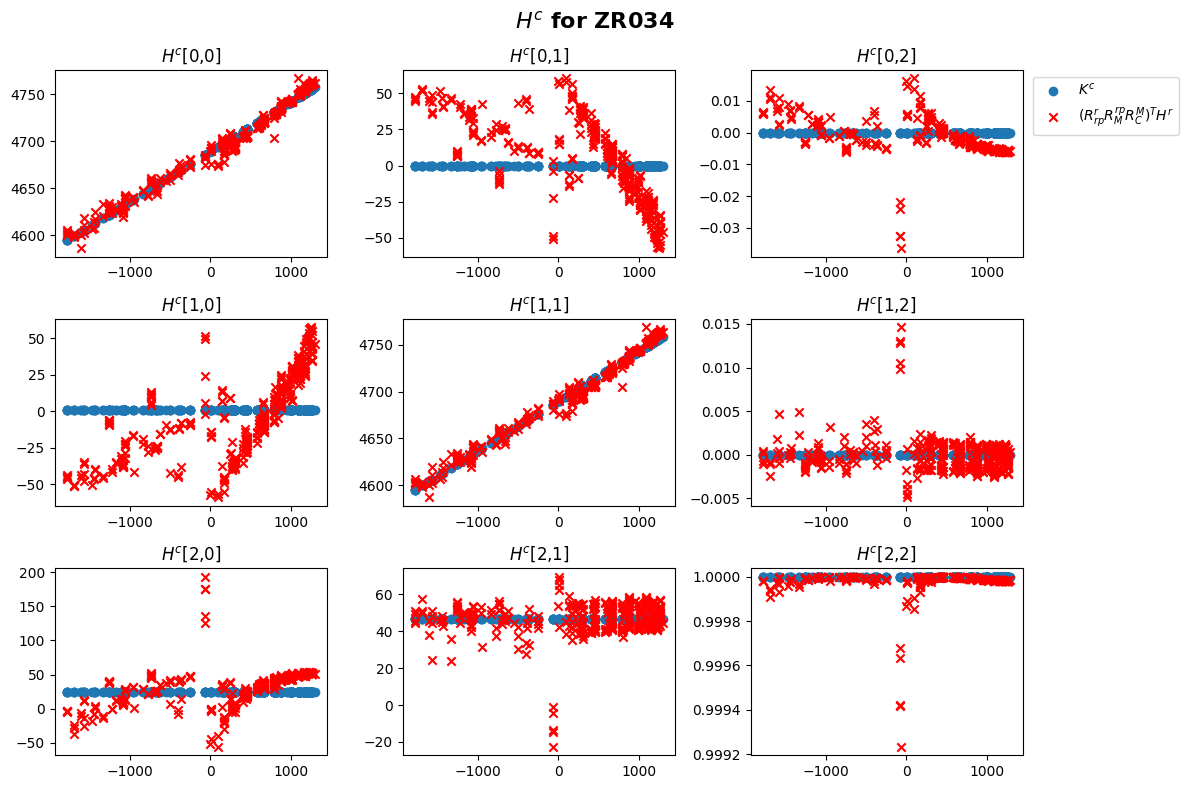

In [154]:
# Compute H_c for ZR034
H_c_model = []
H_c_gt = []

zr034 = data[data["cam"]=="ZR034"].copy().reset_index(drop=True)

rot_rrp = R.from_quat(q_rrp)
for i in range(zr034.shape[0]):
  # compute the rotation R_rc
  f = zr034["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zr034))
  rot_mc = R.from_quat(q_cm_zr_a + q_cm_zr_b * f)
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()

  # tranform to camera frame
  H_r = get_H_r_data(i, zr034)
  H_c_model.append(R_rc.T @ H_r)

  H_c_gt.append(get_KC(i, zr034).T)


fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zr034["fmc"], [H[r,c] for H in H_c_gt], label="expectation")
    ax[r,c].scatter(zr034["fmc"], [H[r, c] for H in H_c_model], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^c$[{r},{c}]")

ax[0,2].legend(["$K^c$", "$(R^r_{rp} R^{rp}_M R^M_C)^T H^r$"], bbox_to_anchor=(1.6,1))

fig.suptitle("$H^c$ for ZR034", fontsize=16, fontweight="bold")
fig.tight_layout()

## Quadratic Model for $q^m_c$

In [156]:
def get_q_rc_model_quad(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                  q_mc_a0, q_mc_a1, q_mc_a2, q_mc_a3,
                  q_mc_b0, q_mc_b1, q_mc_b2, q_mc_b3,
                  q_mc_c0, q_mc_c1, q_mc_c2, q_mc_c3, 
                  idx:int, data_:np.ndarray):
  """
  Forms the quaternion that corresponds to a rotation from r to c from model
  """
  rot_rrp = R.from_quat(np.array([q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3]))

  rot_rpm = R.from_matrix(get_R_rpm(idx, data_))

  rot_mc = R.from_quat(np.array([q_mc_a0, q_mc_a1, q_mc_a2, q_mc_a3]) + \
    np.array([q_mc_b0, q_mc_b1, q_mc_b2, q_mc_b3]) * data_["fmc"][idx] +\
    np.array([q_mc_c0, q_mc_c1, q_mc_c2, q_mc_c3]) * data_["fmc"][idx]**2)
  
  return (rot_rrp * rot_rpm * rot_mc).as_quat(canonical=True)


def dist_q(q1:np.ndarray, q2:np.ndarray)->float:
  assert q1.shape == (4,)
  assert q2.shape == (4,)

  q1 = q1 / np.linalg.norm(q1)
  q2 = q2 / np.linalg.norm(q2)

  return np.arccos(2 * (np.dot(q1, q2)**2) - 1)

data034 = pd.concat([zl34, zr34], axis=0)
data034.reset_index(drop=True, inplace=True)

# objective function for the model
def obj(x)->float:
  
  q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3 = x[:4]
  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3 = x[4:8]
  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3 = x[8:12]
  q_mc_zl_c0, q_mc_zl_c1, q_mc_zl_c2, q_mc_zl_c3 = x[12:16]
  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3 = x[16:20]
  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3 = x[20:24]
  q_mc_zr_c0, q_mc_zr_c1, q_mc_zr_c2, q_mc_zr_c3 = x[24:28]

  total_dist = 0
  count = 0
  for i in range(data034.shape[0]):
    q_rc_data = get_q_rc_data(i, data034)
    if data034["cam"][i] == "ZL034":
      q_rc_model = get_q_rc_model_quad(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3,
                                  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3,
                                  q_mc_zl_c0, q_mc_zl_c1, q_mc_zl_c2, q_mc_zl_c3,
                                  i, data034)
      total_dist += dist_q(q_rc_data, q_rc_model)
      count += 1
    
    elif data034["cam"][i] == "ZR034":
      q_rc_model = get_q_rc_model_quad(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3,
                                  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3,
                                  q_mc_zr_c0, q_mc_zr_c1, q_mc_zr_c2, q_mc_zr_c3,
                                  i, data034)
      total_dist += dist_q(q_rc_data, q_rc_model)
      count += 1
  
  return total_dist/count

x0 = [  0.00035132, -0.0004781 ,  0.00048555, -0.99999971,
      0.5, 0.5, 0.5, -0.5,
      0, 0, 0, 0,
      0, 0, 0, 0,
      0.5, 0.5, 0.5, -0.5,
      0, 0, 0, 0,
      0, 0, 0, 0]
res = minimize(obj, x0, method="BFGS", options={"return_all":True,
                                                "gtol":1e-20,
                                                "xrtol":1e-20,
                                                "maxiter":50})

In [157]:
q_rrp = np.array(res.x[:4])/np.linalg.norm(np.array(res.x[:4]))
q_cm_zl_a = np.array(res.x[4:8])/np.linalg.norm(np.array(res.x[4:8]))
q_cm_zl_b = np.array(res.x[8:12])
q_cm_zl_c = np.array(res.x[12:16])

q_cm_zr_a = np.array(res.x[16:20])/np.linalg.norm(np.array(res.x[16:20]))
q_cm_zr_b = np.array(res.x[20:24])
q_cm_zr_c = np.array(res.x[24:28])


print(f"Final function:{res.fun:.6f}")
print(f"Final Jacobian:{np.linalg.norm(res.jac):.6f}")
print(f"q_rrp:{q_rrp}")
print(f"q_cm_zl_a:{q_cm_zl_a}")
print(f"q_cm_zl_b:{q_cm_zl_b}")
print(f"q_cm_zl_c:{q_cm_zl_c}")
print(f"q_cm_zr_a:{q_cm_zr_a}")
print(f"q_cm_zr_b:{q_cm_zr_b}")
print(f"q_cm_zr_c:{q_cm_zr_c}")

Final function:0.004846
Final Jacobian:915.635987
q_rrp:[-2.04643612e-05 -2.90724645e-04 -8.57883252e-04 -9.99999590e-01]
q_cm_zl_a:[ 0.53912386  0.5339294   0.53374522 -0.37333751]
q_cm_zl_b:[-0.16474786 -0.1688871  -0.16891348 -0.1639756 ]
q_cm_zl_c:[0.00318944 0.00328126 0.00329454 0.00324272]
q_cm_zr_a:[0.50516117 0.49341647 0.50071875 0.50063272]
q_cm_zr_b:[0.05600162 0.05455814 0.05543052 0.05656522]
q_cm_zr_c:[0.00025928 0.00025197 0.00025694 0.00026145]


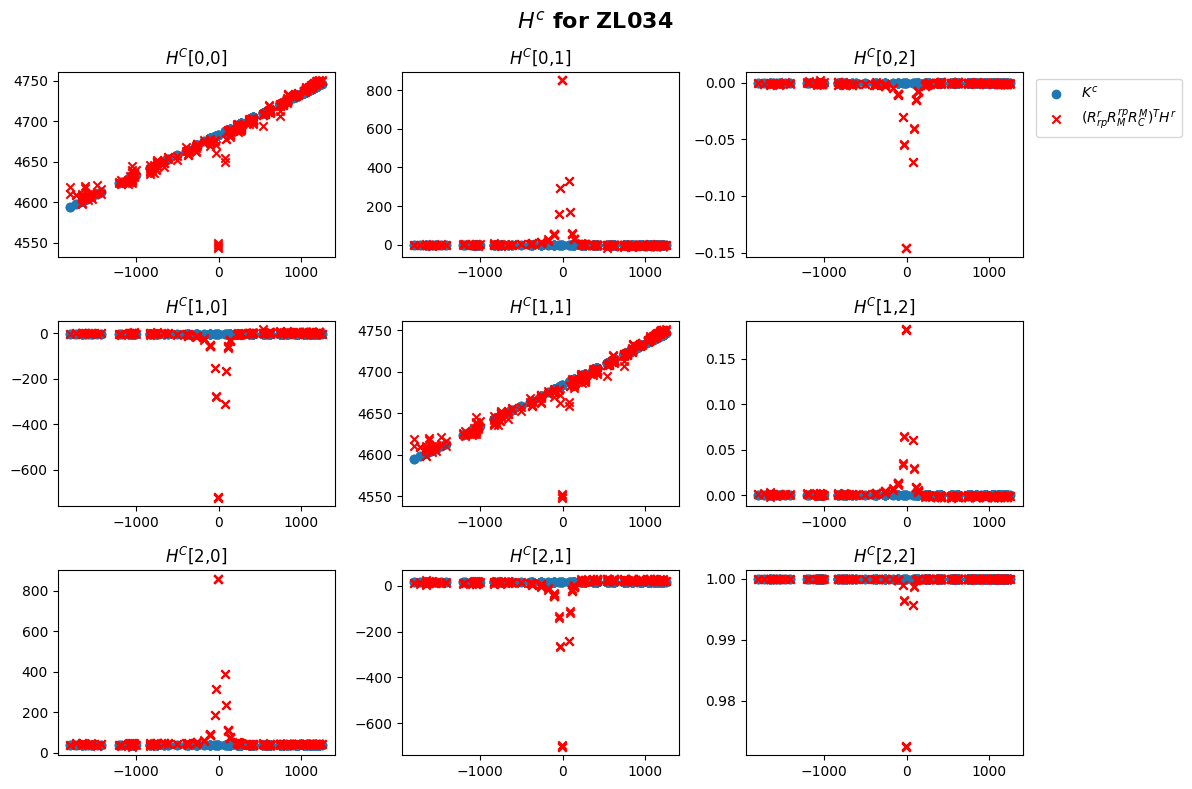

In [159]:
# Compute H_c for ZL034
H_c_model = []
H_c_pseudo_gt = []
H_c_gt = []

zl034 = data[data["cam"]=="ZL034"].copy().reset_index(drop=True)

rot_rrp = R.from_quat(q_rrp)
for i in range(zl034.shape[0]):
  # compute the rotation R_rc
  f = zl034["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zl034))
  rot_mc = R.from_quat(q_cm_zl_a + q_cm_zl_b * f + q_cm_zl_c * f**2)
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()

  # tranform to camera frame
  H_r = get_H_r_data(i, zl034)
  H_c_model.append(np.linalg.inv(R_rc) @ H_r)

  H_c_gt.append(get_KC(i, zl034).T)


fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zl034["fmc"], [H[r,c] for H in H_c_gt], label="expectation")
    ax[r,c].scatter(zl034["fmc"], [H[r, c] for H in H_c_model], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^C$[{r},{c}]")

ax[0,2].legend(["$K^c$", "$(R^r_{rp} R^{rp}_M R^M_C)^T H^r$"], bbox_to_anchor=(1.6,1))


fig.suptitle("$H^c$ for ZL034", fontsize=16, fontweight="bold")
fig.tight_layout()

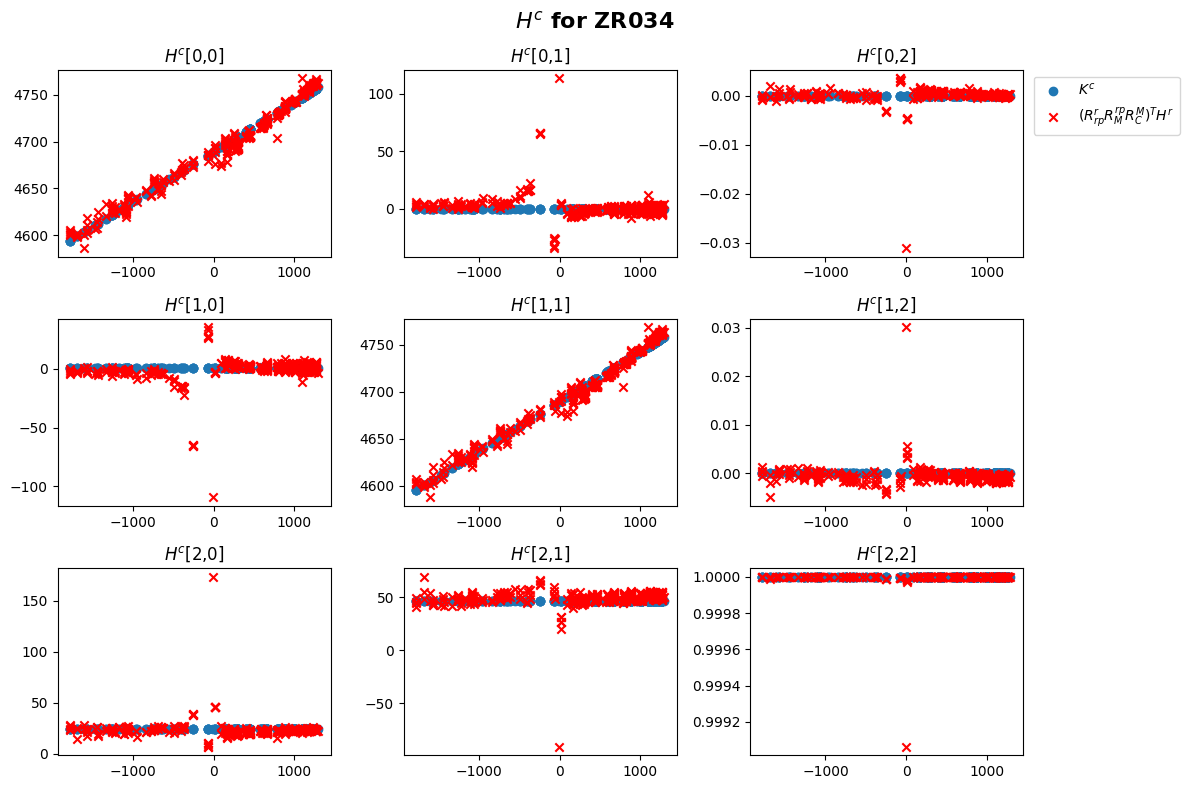

In [160]:
# Compute H_c for ZR034
H_c_model = []
H_c_gt = []

zr034 = data[data["cam"]=="ZR034"].copy().reset_index(drop=True)

rot_rrp = R.from_quat(q_rrp)
for i in range(zr034.shape[0]):
  # compute the rotation R_rc
  f = zr034["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zr034))
  rot_mc = R.from_quat(q_cm_zr_a + q_cm_zr_b * f + q_cm_zr_c * f**2)
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()

  # tranform to camera frame
  H_r = get_H_r_data(i, zr034)
  H_c_model.append(R_rc.T @ H_r)

  H_c_gt.append(get_KC(i, zr034).T)


fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zr034["fmc"], [H[r,c] for H in H_c_gt], label="expectation")
    ax[r,c].scatter(zr034["fmc"], [H[r, c] for H in H_c_model], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^c$[{r},{c}]")

ax[0,2].legend(["$K^c$", "$(R^r_{rp} R^{rp}_M R^M_C)^T H^r$"], bbox_to_anchor=(1.6,1))

fig.suptitle("$H^c$ for ZR034", fontsize=16, fontweight="bold")
fig.tight_layout()